<a href="https://colab.research.google.com/github/Munaza-maker12/neurofive-ml-track/blob/main/Titanic_Survival_%E2%80%94_Your_First_Classification_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install pandas scikit-learn seaborn matplotlib -q

import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

In [4]:
df = sns.load_dataset("titanic")
df = df[["survived", "pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]].copy()
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [5]:
df["age"] = df["age"].fillna(df["age"].median())
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])
df["fare"] = df["fare"].fillna(df["fare"].median())

print(df.isnull().sum())

survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
dtype: int64


In [6]:
df_encoded = pd.get_dummies(df, columns=["sex", "embarked"], drop_first=True)
df_encoded.head()


,survived,pclass,age,sibsp,parch,fare,sex_male,embarked_Q,embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


In [7]:
X = df_encoded.drop("survived", axis=1)
y = df_encoded["survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 712
Test size: 179


In [11]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [13]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

Accuracy: 0.8045 (80.45%)


NameError: name 'cm' is not defined

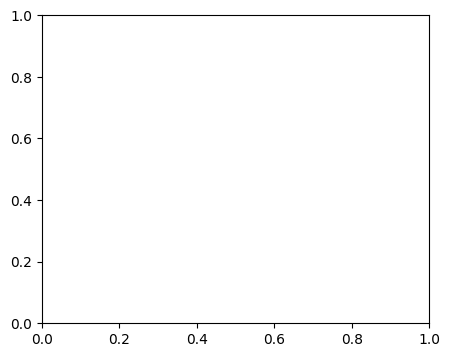

In [14]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["Did Not Survive", "Survived"])
ax.set_yticklabels(["Did Not Survive", "Survived"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title(f"Confusion Matrix (Accuracy: {accuracy:.2%})")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=14)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()